In [1]:
# /// script
# requires-python = ">=3.13"
# dependencies = [
#     "careamics[examples]>=0.3.0, <0.4.0",
# ]
# [tool.uv.sources]
# careamics = {git = "https://github.com/CAREamics/careamics", branch = "dev/ome_zarr_sister"}
# ///

<img src="https://careamics.github.io/latest/images/banner_careamics_large.png">

# Data loading, OME-NGFF and Noise2Void

Updated 30.09.26

In this notebook, we explore CAREamics data loading, use an OME-NGFF Zarr file, and
train Noise2Void.


<div style="
  background: #fff8db;
  border-left: 6px solid #e2b200;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #8a6a00;
">
  <strong style="color: #8a6a00;">Important</strong><br>
  
  This notebook is using an experimental branch for OME-NGFF at the time of the writing, API, implementation
  and features might change in the future.
</div>


In [45]:
from pathlib import Path
from collections.abc import Sequence

import matplotlib.pyplot as plt
import numpy as np
import pooch
import zarr
import yaozarrs

from careamics import CAREamist
from careamics.config import create_advanced_n2v_config

from careamics.dataset.patching import (
    Patching,
    RandomPatching,
    StratifiedPatching,
)
from careamics.dataset.factory.val_split import create_val_split
from careamics.plotting import plot_loss
from careamics.dataset.patch_filter import (
    MaxPatchFilter,
)


SEED = 24
rng = np.random.default_rng(SEED)

# 1 - Example data

The example data is extracted from [10.5281/zenodo.22078388](https://doi.org/10.5281/zenodo.22078388), and is a small excerpt
from a larger experiment.

In [2]:
def download_data() -> Path:
    """Download example data.

    Returns
    -------
    Path
        Path to data.
    """
    root = Path("") / "data"
    root.mkdir(exist_ok=True)

    file_list = pooch.retrieve(
        "https://zenodo.org/records/22078388/files/001-mini.zip?download=1",
        known_hash="a253ebdda4300231c5a890908158cda8efe47cf8de9fddb101ae1eb6c10b824d",
        processor=pooch.Unzip(),
        path=root,
    )

    for f in file_list:
        if f.endswith("raw.ome.zarr/zarr.json"):
            return Path(f).parent

    return f

file_path = download_data()

In [3]:
# Check out Zarr file
z = zarr.open(file_path)
print(z.tree())

# Validate that it is OME-NGFF compliant (no error raised)
_ = yaozarrs.validate_zarr_store(file_path)

/
├── 0 (5, 2, 76, 389, 610) uint16
├── 1 (5, 2, 76, 194, 305) uint16
├── 2 (5, 2, 76, 96, 152) uint16
├── 3 (5, 2, 76, 47, 76) uint16
└── 4 (5, 2, 76, 23, 38) uint16



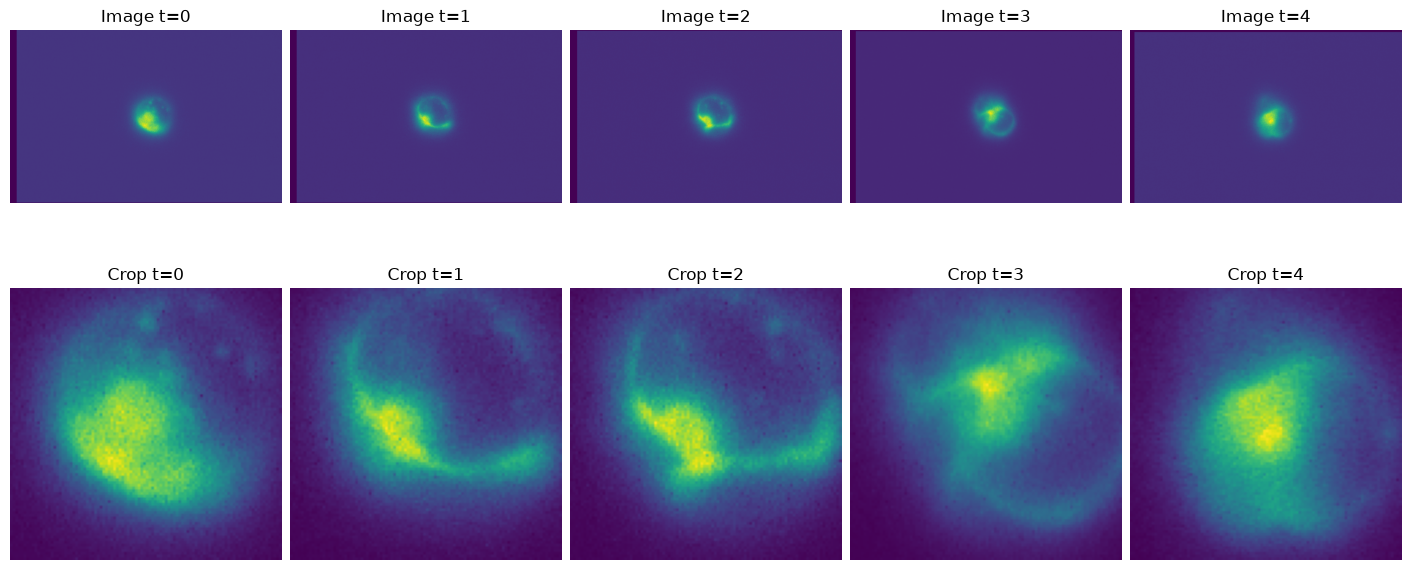

In [4]:
scale = "0"
chan = 0
z_mid = 38
xy_crop = (slice(150, 250), slice(265, 365))

img = z[scale][:, chan, z_mid]

fig, axes = plt.subplots(2, img.shape[0], figsize=(14,6), constrained_layout=True)

for t in range(img.shape[0]):
    axes[0, t].imshow(img[t])
    axes[0, t].axis("Off")
    axes[0, t].set_title(f"Image t={t}")

    axes[1, t].imshow(img[t][*xy_crop])
    axes[1, t].axis("Off")
    axes[1, t].set_title(f"Crop t={t}")


## 2 - How patches are extracted in CAREamics

CAREamics has a modularized data loading pipeline, relying on an ensemble of interacting
classes. One of the novelty of the recent profound overhaul of the code base is the
introduction of such dataset and data loading modules.

In particular, we have implemented a new patching strategy: stratified patching. This
way of patching the sample allows excluding certain areas (see the next sections) from
the sampling, while giving similar probabilities of selecting each area during an epoch.
Finally, it also maximizes coverage by selecting patches that are far from each other (hence
the name).

Let's have a look at patches selection.


In [5]:
def demo_selected_patches(
    patching_strategy: Patching,
    data_shapes: Sequence[Sequence[int]],
    epochs: int,
) -> Sequence[np.ndarray]:
    """Create a map where all the patches have been selected from.

    Every time a patch is selected that area is incremented by 1.
    """
    tracking_arrays = [np.zeros(shape, dtype=int) for shape in data_shapes]
    for _ in range(epochs):
        for index in range(patching_strategy.n_patches):
            patch_spec = patching_strategy.get_patch_spec(index)
            data_idx = patch_spec["data_idx"]
            sample_idx = patch_spec["sample_idx"]
            coord = patch_spec["coords"]
            patch_size = patch_spec["patch_size"]

            patch_slice = [
                slice(c, c + ps) for c, ps in zip(coord, patch_size, strict=True)
            ]
            tracking_arrays[data_idx][sample_idx, ..., *patch_slice] += 1
    return tracking_arrays


Text(0.5, 0.98, 'Comparing patching strategies')

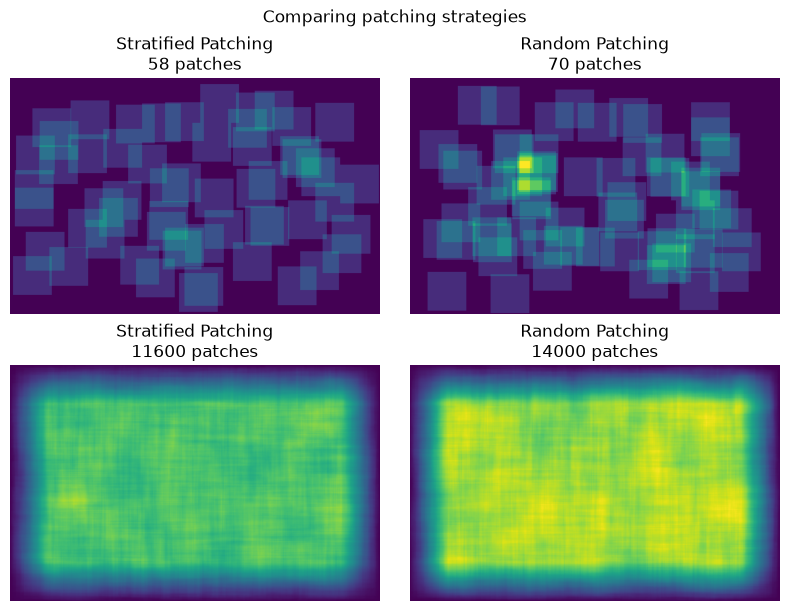

In [6]:
# We don't need data, just shapes
data_shapes = [(1, 1, 389, 610)]  # we need CAREamics internal SC(Z)YX dimensions
patch_size = (64, 64)

# The old and the "new" patching strategies in CAREamics
stratified_patching = StratifiedPatching(data_shapes, patch_size, seed=SEED)
random_patching = RandomPatching(data_shapes, patch_size, seed=SEED)

n_patches_strat = stratified_patching.n_patches
n_patches_rand = random_patching.n_patches

# Number of epochs to plot
epochs = [1, 200]

fig, axes = plt.subplots(len(epochs), 2, figsize=(8, 6), constrained_layout=True)

for i, e in enumerate(epochs):
    stratified_selected = demo_selected_patches(stratified_patching, data_shapes, e)[0]
    random_selected = demo_selected_patches(random_patching, data_shapes, e)[0]

    stack = np.stack([stratified_selected, random_selected])
    vmin, vmax = stack.min(), stack.max()

    n_strat = n_patches_strat * e
    n_rand = n_patches_rand * e

    axes[i, 0].imshow(stratified_selected.squeeze(), vmin=vmin, vmax=vmax)
    axes[i, 0].set_title(f"Stratified Patching\n{n_strat} patches")
    axes[i, 0].axis("Off")

    axes[i, 1].imshow(random_selected.squeeze(), vmin=vmin, vmax=vmax)
    axes[i, 1].set_title(f"Random Patching\n{n_rand} patches")
    axes[i, 1].axis("Off")

fig.suptitle("Comparing patching strategies")



<div style="
  background: #f3f4f6;
  border-left: 6px solid #6b7280;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #374151;
">
  <strong>Note</strong><br>

  Random patching used to be the default in CAREamics, but it has been replaced by the
  stratified patching. It is still possible to use random patching by changing parameters
  (`patch_filter_config`) in the advanced configuration.

  An additional difference is that there is small overhead at the start of the training
  with the stratified patching, in order to set up the grid of patching areas.
</div>

<div style="
  background: #e8f7ec;
  border-left: 6px solid #2f9e44;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #1f5f2c;
">
  <strong style="color: #1f5f2c;">Question</strong><br>

  How often is a pixel selected in both `epochs=200` maps?
</div>

In [7]:
mean = np.mean(stratified_selected/epochs[-1])
std = np.std(stratified_selected/epochs[-1])
print("--- Stratified Strategy ---")
print("Expected value that a pixel is selected in an epoch")
print(f"Mean: {mean:.3f}, StdDev: {std:.3f}")
print("\n")

mean = np.mean(random_selected/epochs[-1])
std = np.std(random_selected/epochs[-1])
print("--- Random Strategy ---")
print("Expected value that a pixel is selected in an epoch")
print(f"Mean: {mean:.3f}, StdDev: {std:.3f}")


--- Stratified Strategy ---
Expected value that a pixel is selected in an epoch
Mean: 1.001, StdDev: 0.447


--- Random Strategy ---
Expected value that a pixel is selected in an epoch
Mean: 1.208, StdDev: 0.541


## 3 - Excluding patches

The main motivation behind the fancy stratified patching is to be able to split images
into two different set of areas. There is several use cases for this:

- Split train and validation (especially for Noise2Void)
- Exclude part of the images (patch filtering)

Text(0.5, 1.0, 'Excluded patches')

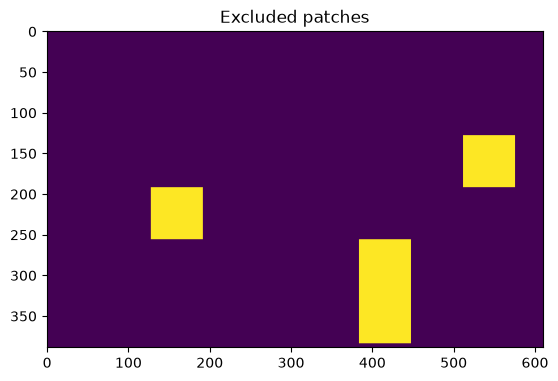

In [8]:
# Choose some patches to exclude (in patch space)
exclude_patches = [(3, 2), (5, 6), (4, 6), (2, 8)] # patch space
exlc_mask = np.zeros(data_shapes[0], dtype=bool)
for grid_coord in exclude_patches:
    patch_slice = [
        slice(c * ps, (c + 1) * ps)
        for c, ps in zip(grid_coord, patch_size, strict=True)
    ]
    exlc_mask[..., *patch_slice] = True
plt.imshow(exlc_mask[0, 0])
plt.title("Excluded patches")

In [9]:
# Exclude patches
stratified_patching.exclude_patches(
    data_idx=0, sample_idx=0, grid_coords=exclude_patches
)

(np.float64(-0.5), np.float64(609.5), np.float64(388.5), np.float64(-0.5))

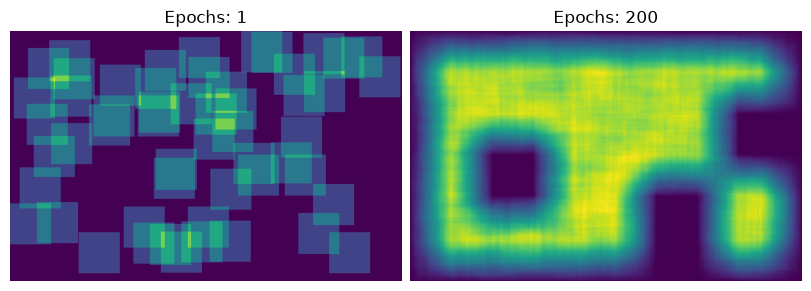

In [10]:
# Plot results
stratified_1 = demo_selected_patches(stratified_patching, data_shapes, epochs=1)
stratified_200 = demo_selected_patches(stratified_patching, data_shapes, epochs=200)

fig, axes = plt.subplots(1, 2, figsize=(8, 6), constrained_layout=True)
axes[0].imshow(stratified_1[0][0, 0])
axes[0].set_title("Epochs: 1")
axes[0].axis("Off")
axes[1].imshow(stratified_200[0][0, 0])
axes[1].set_title("Epochs: 200")
axes[1].axis("Off")

### Train-validation splitting

To avoid users having to split themselves train and validation, and to not have to
hold all patches in memory, we use the exclusion mechanism from the stratigied patching
to split both sets.

Selecting 17 validation patches from 167 total patches.


Text(0, 0.5, 'Validation')

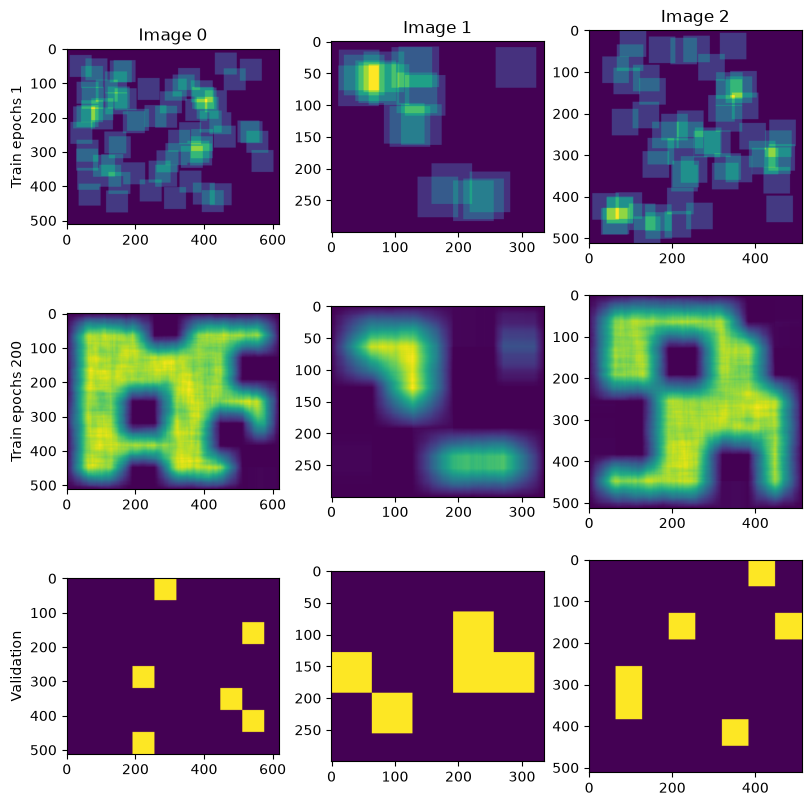

In [11]:
data_shapes = [(1, 1, 512, 620), (1, 1, 300, 335), (1, 1, 512, 512)]
patch_size = (64, 64)

stratified_patching = StratifiedPatching(data_shapes, patch_size, seed=42)
n_val_patches = int(np.ceil(stratified_patching.n_patches * 0.1))  # 10% of patches
print(
    f"Selecting {n_val_patches} validation patches from "
    f"{stratified_patching.n_patches} total patches."
)
train_patching, val_patching = create_val_split(stratified_patching, n_val_patches, rng)

train_1 = demo_selected_patches(train_patching, data_shapes, epochs=1)
train_200 = demo_selected_patches(train_patching, data_shapes, epochs=200)
val = demo_selected_patches(val_patching, data_shapes, epochs=1)


fig, axes = plt.subplots(3, len(data_shapes), figsize=(8, 8), constrained_layout=True)
for i in range(len(data_shapes)):
    axes[0, i].set_title(f"Image {i}")
    axes[0, i].imshow(train_1[i][0, 0], aspect='equal')
    axes[1, i].imshow(train_200[i][0, 0], aspect='equal')
    axes[2, i].imshow(val[i][0, 0], aspect='equal')
axes[0, 0].set_ylabel("Train epochs 1")
axes[1, 0].set_ylabel("Train epochs 200")
axes[2, 0].set_ylabel("Validation")

### Patch filtering

Patch filtering allows to remove part of the image from patching. We provide several 
statistical measures to define what should be excluded from the image. Alternatively, 
you can also provide a mask to CAREamics.

Let's test one such statistical measure.

<div style="
  background: #f3f4f6;
  border-left: 6px solid #6b7280;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #374151;
">
  <strong>Note</strong><br>

  Excluded areas using the patch filtering is actually different from the train-validation
  split. Indeed the filtered areas still have a very small probability of being selected.
  The goal being to exclude for instance background, while still every now and then provide
  it to the model.
</div>

Shape (389, 610)


Text(0, 0.5, 'threshold')

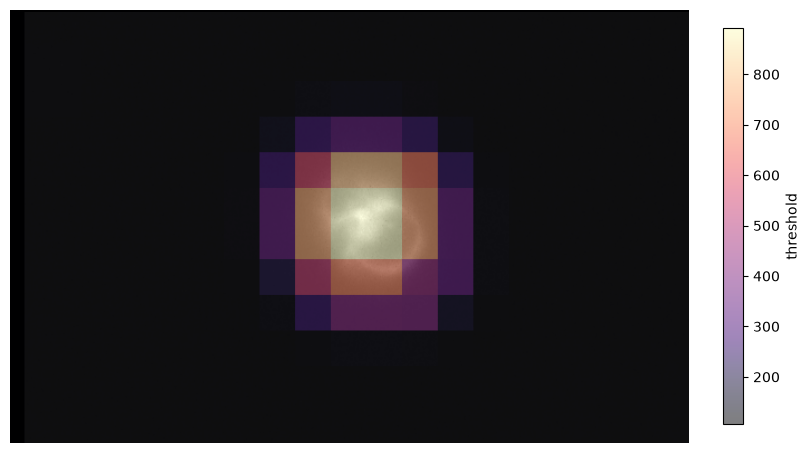

In [46]:
img = z[scale][3, chan, z_mid]
print(f"Shape {img.shape}")

max_filter_map = MaxPatchFilter.filter_map(img, (32, 32))

fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
ax.imshow(img, "gray")
ax.axis("Off")
m = ax.imshow(max_filter_map, "magma", alpha=0.5)
cbar = plt.colorbar(m, ax=ax, shrink=0.5)
cbar.ax.set_ylabel("threshold")

<div style="
  background: #f3f4f6;
  border-left: 6px solid #6b7280;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #374151;
">
  <strong>Note</strong><br>

  There are two ways to use the measurements:

  - Pass on the parameters (e.g. threshold) to the configuration and CAREamics will
  compute the statistics over the entire image to exclude areas. There, you need to
  use the same patch size to ensure that your are not over or under filtering.
  - Generate a mask and pass the mask to CAREamics.
</div>

In [60]:
img = z[scale][:, chan] # TZYX dimensions

mask = np.stack([
    MaxPatchFilter.apply_filter(
        MaxPatchFilter.filter_map(img[t], patch_size=(1, 32, 32)),
        threshold=200
    )
    for t in range(img.shape[0])
], axis=0)

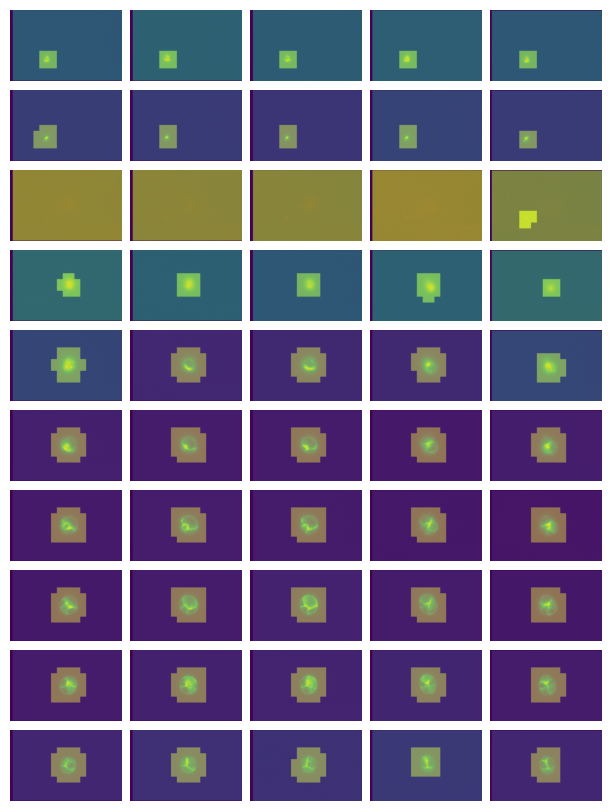

In [62]:
z_slices = list(range(z_mid-10, z_mid+10, 2))
fig, axes = plt.subplots(len(z_slices), img.shape[0], figsize=(6, 8), constrained_layout=True)

for t in range(img.shape[0]):
    for i, z_slice in enumerate(z_slices):
        axes[i, t].imshow(img[t, z_slice])
        axes[i, t].axis("Off")

        axes[i, t].imshow(mask[t, z_slice], alpha=0.4)
        

## 4 - Training Noise2Void on a Zarr

CAREamics supports several [file format](https://careamics.github.io/latest/content/guides/current/data/), but not OME-NGFF files (yet!). In this experimental branch, we have added support for OME-NGFF compatible Zarr files. Currently, it only takes the smallest scale, although an internal parameter can change that. In the future, we may add it to the main API to allow users to select the scale as well.


In [63]:
exp = "n2v_lightsheet_denoising"
root = Path("") / exp
root.mkdir(exist_ok=True)

config = create_advanced_n2v_config(
    experiment_name=exp,
    data_type="zarr",
    axes="TCZYX",
    patch_size=(4, 128, 128),
    # because we are training 3D, this may take a while
    # so we choose lower settings for the sake of the demonstration
    batch_size=4,
    num_epochs=5,
    num_steps = 20,
    channels=[0], # only train on the first channel
    normalization_params={"input_means": [105.27], "input_stds": [31.41]} # pre-computed, remove and see log
)
careamist = CAREamist(config=config, work_dir=root)
careamist.train(
    train_data=file_path,
    filtering_mask=mask
)


/Users/joran.deschamps/git/careamics/i2k_workshop/.venv/lib/python3.13/site-packages/pydantic/main.py:263: UserWarning: Warning: Batch normalization is used with batch size 4. We advise using a batch size of at least 8 when using batch normalization, as smaller batch sizes may be unreliable. Consider increasing the batch size or disabling batch normalization in the algorithm `model` parameter.
  validated_self = self.__pydantic_validator__.validate_python(data, self_instance=self)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


ValueError: Invalid argument combination for data initialization. The data type is set to `zarr`, but received non-compatible input type `<class 'numpy.ndarray'>`. For `zarr` data type, the expected input is a str, a pathlib.Path, or a sequence of either. Refer to the documentation for more details.

In [14]:
# Plot losses and save the figure to disk
results = root / "results"
results.mkdir(exist_ok=True, parents=True)

plot_loss(
    careamist.get_losses(),
    plot_learning_rate=False,
    plot_metrics=False,
    save_path=results / "loss.png"
)



NameError: name 'root' is not defined

In [22]:
# Prediction directly to disk using tiling
careamist.predict_to_disk(
    pred_data=file_path,
    batch_size=4,
    tile_size=(8, 256, 256),
    tile_overlap=(2, 48, 48),
)

Creating prediction output directory: '/Users/joran.deschamps/git/careamics/i2k_workshop/n2v_ome_zarr/n2v_lightsheet_denoising/predictions'
Restoring states from the checkpoint path at /Users/joran.deschamps/git/careamics/i2k_workshop/n2v_ome_zarr/n2v_lightsheet_denoising/checkpoints/n2v_lightsheet_denoising_0/n2v_lightsheet_denoising_last.ckpt
Loaded model weights from the checkpoint at /Users/joran.deschamps/git/careamics/i2k_workshop/n2v_ome_zarr/n2v_lightsheet_denoising/checkpoints/n2v_lightsheet_denoising_0/n2v_lightsheet_denoising_last.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

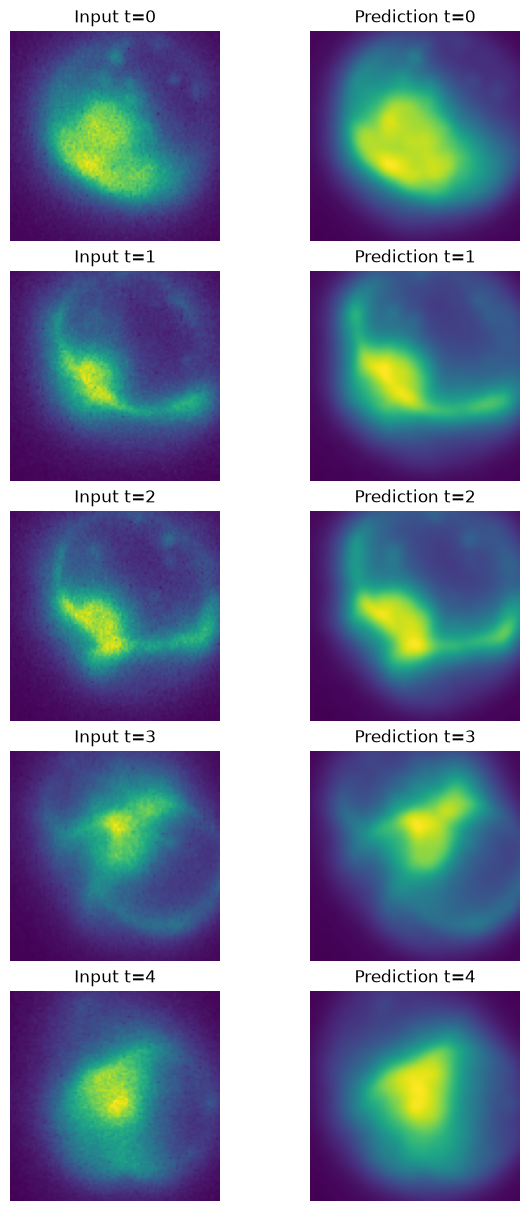

In [24]:
# Check that the output exists and is OME-NGFF compliant
pred_path = root / "predictions" / "raw.ome_output.zarr"
assert pred_path.exists()
    
z_pred = zarr.open(pred_path)
img = z[scale][:, chan, z_mid]
pred = z_pred[scale][:, 0, z_mid]
assert img.shape == pred.shape

fig, axes = plt.subplots(img.shape[0], 2, figsize=(6, 12), constrained_layout=True)
for t in range(img.shape[0]):
    axes[t, 0].imshow(img[t][*xy_crop])
    axes[t, 0].axis("Off")
    axes[t, 0].set_title(f"Input t={t}")

    axes[t, 1].imshow(pred[t][*xy_crop])
    axes[t, 1].axis("Off")
    axes[t, 1].set_title(f"Prediction t={t}")






## Optional exercises

<div style="
  background: #accffb;
  border-left: 6px solid #2f80ed;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #21457f;
">
  <strong style="color: #21457f;">Optional exercise: use custom formats with CAREamics</strong><br>

  Try the [tutorial on custom formats](https://careamics.github.io/latest/content/guides/tutorials/custom_data/).
</div>

<div style="
  background: #accffb;
  border-left: 6px solid #2f80ed;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #21457f;
">
  <strong style="color: #21457f;">Optional exercise: advanced custom loading with CAREamics</strong><br>

  For more advanced data loading, CAREamics has another mechanism to allow you to define
  how to load data. Try the [tutorial on custom ImageStack](https://careamics.github.io/latest/content/guides/tutorials/implementing_an_image_stack/).
</div>
